# Exploratory Data Analysis

In [12]:
import pandas as pd 
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# load data
df = pd.read_csv('../data/clean/clean_cars_from_japan.csv')
df

,year,make,model_code,mileage_km,engine_cc,transmission,grade,price_usd
0,2021,DAIHATSU,3BD-S510P,"56,000.00",660,Automatic,NaN,"7,929.00"
1,2021,MERCEDES-BENZ,3BA-463276,"10,000.00",4000,Automatic,4.50,"126,540.00"
2,2019,TOYOTA,6AA-AXAH54,"37,300.00",2500,Automatic,NaN,"19,142.00"
3,2019,TOYOTA,MXAA52,"14,700.00",2000,Automatic,NaN,"20,910.00"
4,2019,TOYOTA,6BA-MXAA54,"21,900.00",2000,Automatic,NaN,"16,940.00"
...,...,...,...,...,...,...,...,...
12995,2019,TOYOTA,QDF-GDH206Kカイ,"28,000.00",2800,Automatic,4.00,"37,150.00"
12996,2022,BMW,3BA-6V15W,"13,000.00",1500,Automatic,NaN,"25,207.00"
12997,2021,SUBARU,4BA-SK5,"31,700.00",1800,Automatic,NaN,"18,300.00"
12998,2020,TOYOTA,6AA-AXUH85,"22,000.00",2500,Automatic,4.00,"23,965.00"


In [4]:
# Basic inpections
print("Basic inspection results\n")
print(f"Shape : {df.shape}\n")
print(f"Columns: {list(df.columns)}\n")

print("First 5 rows")
print(df.head())

print("\nSummary statistic")
print(df.describe().round(2))

Basic inspection results

Shape : (13000, 8)

Columns: ['year', 'make', 'model_code', 'mileage_km', 'engine_cc', 'transmission', 'grade', 'price_usd']

First 5 rows
   year           make  model_code  mileage_km  engine_cc transmission  grade  \
0  2021       DAIHATSU   3BD-S510P   56,000.00        660    Automatic    NaN   
1  2021  MERCEDES-BENZ  3BA-463276   10,000.00       4000    Automatic   4.50   
2  2019         TOYOTA  6AA-AXAH54   37,300.00       2500    Automatic    NaN   
3  2019         TOYOTA      MXAA52   14,700.00       2000    Automatic    NaN   
4  2019         TOYOTA  6BA-MXAA54   21,900.00       2000    Automatic    NaN   

   price_usd  
0   7,929.00  
1 126,540.00  
2  19,142.00  
3  20,910.00  
4  16,940.00  

Summary statistic
           year  mileage_km  engine_cc    grade      price_usd
count 13,000.00   12,875.00  13,000.00 5,358.00      12,849.00
mean   2,021.14   34,855.43   2,123.38     4.40      41,337.63
std        1.80   24,271.56   2,869.38     0.43   

In [5]:
# Missing Values
print("Missing Values")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'count':missing,
    'percentage':missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing Values
            count  percentage
grade        7642       58.78
price_usd     151        1.16
mileage_km    125        0.96


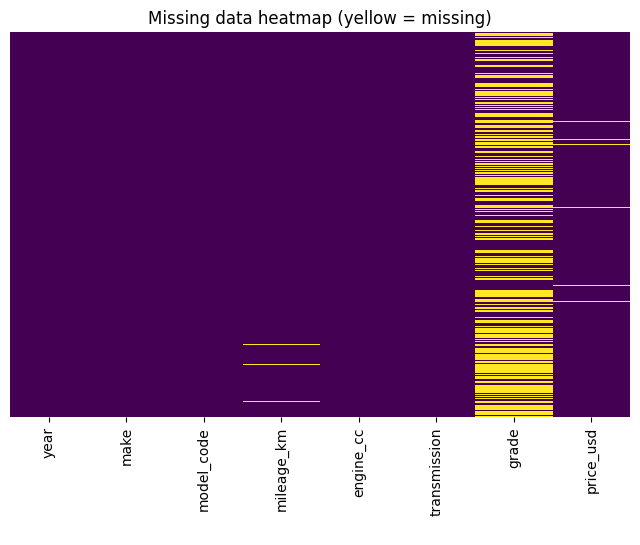

In [6]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [7]:
# 4. Target Distribution
TARGET = "price_usd"
print("Target Distribution")
print(df[TARGET].describe())

Target Distribution
count        12,849.00
mean         41,337.63
std       1,413,362.03
min           4,212.00
25%          16,680.00
50%          23,494.00
75%          31,788.00
max     160,025,840.00
Name: price_usd, dtype: float64


In [8]:
# Clip extreme outliers
df = df[df["price_usd"] < df["price_usd"].quantile(0.99)]

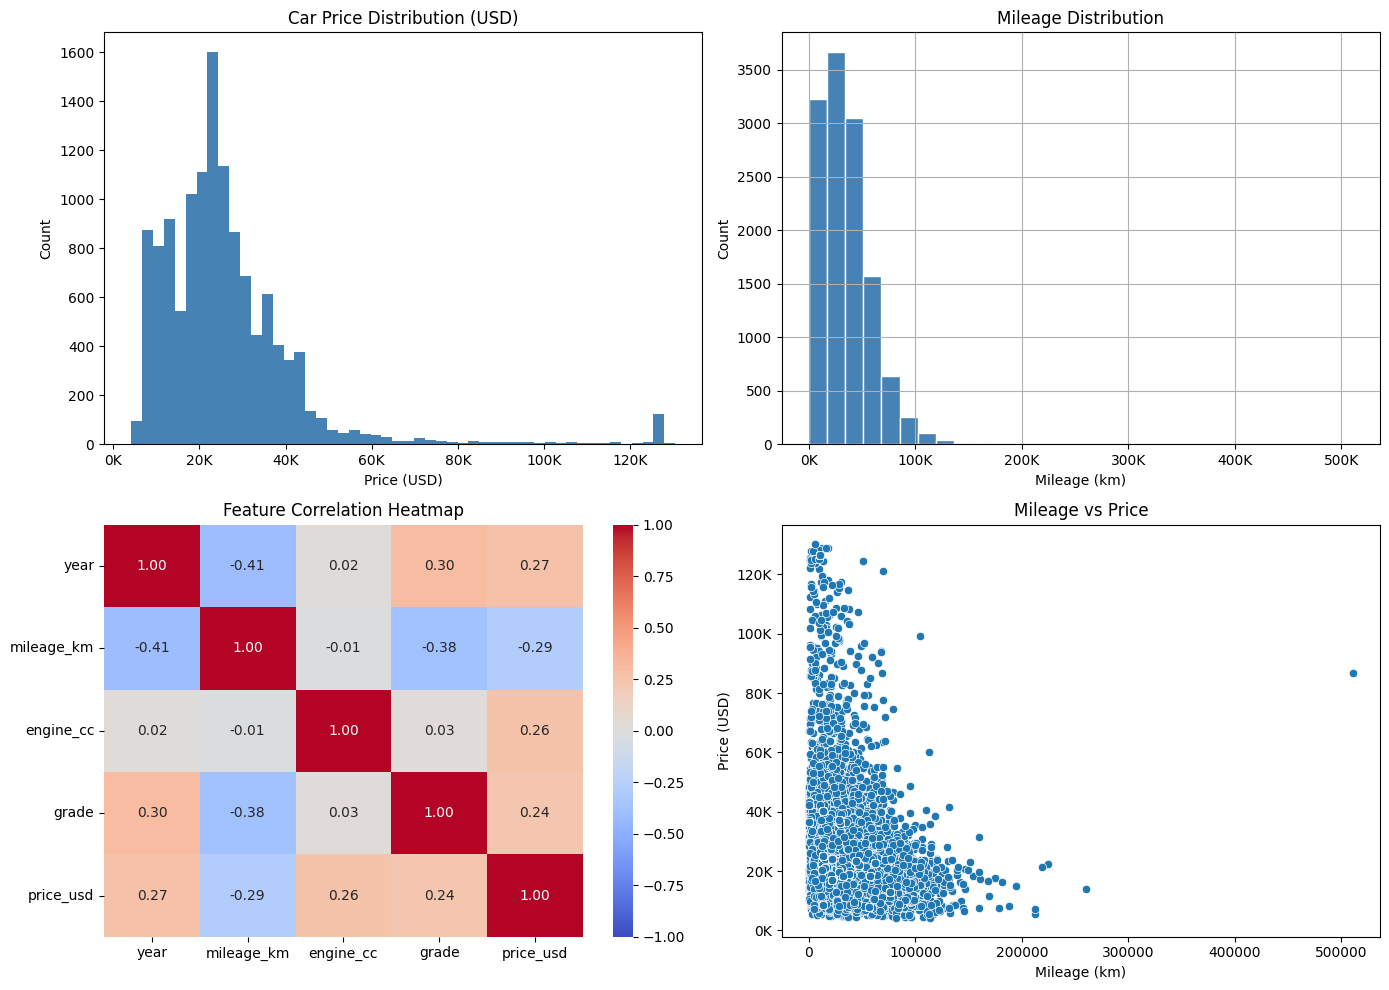

In [9]:
# Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution (Price)

df[TARGET].dropna().plot(kind="hist", bins=50, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Car Price Distribution (USD)")
axes[0, 0].set_xlabel("Price (USD)")
axes[0, 0].set_ylabel("Count")

# format in millions/thousands
axes[0, 0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

# Mileage distribution
df["mileage_km"].dropna().hist(
    ax=axes[0, 1],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

axes[0, 1].set_title("Mileage Distribution")
axes[0, 1].set_xlabel("Mileage (km)")
axes[0, 1].set_ylabel("Count")

# optional formatting (convert to thousands)
axes[0, 1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)


# Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=np.number).columns

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Feature Correlation Heatmap")

# Mileage vs Price 
sns.scatterplot(
    x=df["mileage_km"],
    y=df[TARGET],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Mileage vs Price")
axes[1, 1].set_xlabel("Mileage (km)")
axes[1, 1].set_ylabel("Price (USD)")

axes[1, 1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

<Axes: xlabel='price_usd'>

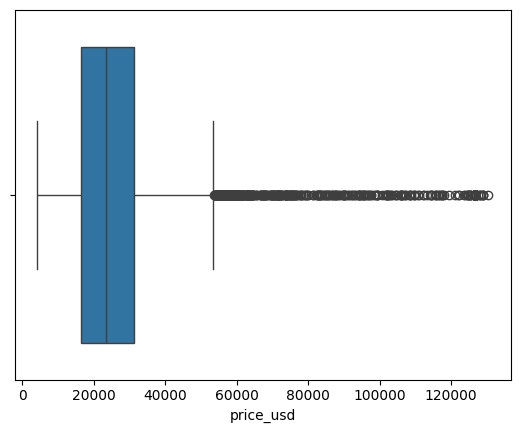

In [11]:
# target outliers
sns.boxplot(x=df["price_usd"])

## EDA Findings 
1. How many rows and columns?
   |rows | column |
   |---- | ----- |
   |500 | 8 |

2. Which columns have missing data and how much?

     |      | count | percentage |
     |---- | -------  | ----- |
    | grade    |     336    |    67.2 |
    | mileage_km |     1     |    0.2 | 
    | price_usd   |    1     |    0.2 |
   
3. Is the target class balanced or imbalanced?
    - The target variable (price_usd) show a strongly right-skewed distrbition.
    - The target variable (price_usd) ranges from `~$4,900` – `~$130,000`
    - Mean price - `$26,500`
    - Median price - `$23,500`
4. Which features appear most correlate with the target?
    - `engine_cc` → strong positive correlation
    - `mileage_km` → negative correlation
    - `year` → positive correlation (newer = more expensive)
5. Are there any obvious outliers to address?
    - Extremely expensive cars (e.g. AMG, Alphard)
    - Very low mileage (0–100 km “new imports”)
    - Very high mileage (>150,000 km)
